# Lab 11 — Recurrent Neural Networks

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/wanghemath/Book-MathNLP/blob/main/labs/chapter-11-recurrent-neural-networks.ipynb)

This lab accompanies **Chapter 11: Recurrent Neural Networks** in the Math NLP book.

A bag-of-words model represents a sentence as an unordered set or multiset of words. A recurrent neural network represents a sentence as an **ordered sequence**. At time step $t$, the model reads token $x_t$, updates a hidden state $h_t$, and uses that hidden state as a summary of the prefix $(x_1, \ldots, x_t)$.

The central mathematical recurrence is

$$
h_t = \tanh(W_h h_{t-1} + W_x e_t + b_h),
$$

where $e_t$ is the embedding of token $x_t$.

## What you will learn

By the end of this lab, you should be able to:

1. explain why word order matters in NLP;
2. implement a vanilla RNN forward pass from scratch;
3. visualize hidden states as a trajectory in a state space;
4. train a small many-to-one RNN classifier by backpropagation through time;
5. identify vanishing and exploding gradients using matrix products;
6. apply gradient clipping;
7. compare RNN sequence modeling with bag-of-words modeling.

This notebook is designed for independent study. Read the background paragraphs carefully before running each code block.

## 0. Setup

This lab uses only standard scientific Python packages. No external dataset is needed. The corpus is intentionally small so that the mathematics remains visible.

In [1]:
import re
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(11)

## 1. Why recurrence? A failure case for bag-of-words

A bag-of-words model counts tokens but ignores their order. Therefore the sentences

$$
\text{not good} \qquad \text{and} \qquad \text{good not}
$$

have the same bag-of-words vector. In real language, these two strings may not be equally natural or equally meaningful. A sequence model can distinguish them because it processes tokens in order.

We begin with a tiny sentiment-style dataset where the token **not** changes the meaning of nearby words. This dataset is deliberately small and artificial. Its purpose is to isolate the mathematical idea.

In [2]:
examples = [
    ("good", 1),
    ("very good", 1),
    ("really good", 1),
    ("excellent", 1),
    ("not bad", 1),
    ("not terrible", 1),
    ("not boring", 1),
    ("movie good", 1),
    ("story excellent", 1),
    ("acting not bad", 1),
    ("bad", 0),
    ("very bad", 0),
    ("really bad", 0),
    ("terrible", 0),
    ("boring", 0),
    ("not good", 0),
    ("not excellent", 0),
    ("movie bad", 0),
    ("story terrible", 0),
    ("acting not good", 0),
]

# A few examples reserved for a simple generalization check.
test_examples = [
    ("good", 1),
    ("not good", 0),
    ("bad", 0),
    ("not bad", 1),
    ("story not terrible", 1),
    ("movie not excellent", 0),
]

def tokenize(text):
    return re.findall(r"[a-z]+", text.lower())

tokenized = [(tokenize(text), y) for text, y in examples]
print(tokenized[:5])

[(['good'], 1), (['very', 'good'], 1), (['really', 'good'], 1), (['excellent'], 1), (['not', 'bad'], 1)]


### Vocabulary and integer encoding

Neural sequence models usually map tokens to integer ids. These ids are then used to retrieve embedding vectors or one-hot columns.

We include two special tokens:

- `<pad>` for padding, if needed later;
- `<unk>` for unknown words.

In [3]:
special_tokens = ["<pad>", "<unk>"]
word_counts = Counter(tok for toks, _ in tokenized for tok in toks)
vocab = special_tokens + sorted(word_counts)
stoi = {w: i for i, w in enumerate(vocab)}
itos = {i: w for w, i in stoi.items()}

print("Vocabulary size:", len(vocab))
print(vocab)

def encode(tokens):
    return [stoi.get(tok, stoi["<unk>"]) for tok in tokens]

encoded = [(encode(toks), y) for toks, y in tokenized]
for toks, ids_y in zip(tokenized[:6], encoded[:6]):
    print(toks, "->", ids_y)

Vocabulary size: 13
['<pad>', '<unk>', 'acting', 'bad', 'boring', 'excellent', 'good', 'movie', 'not', 'really', 'story', 'terrible', 'very']
(['good'], 1) -> ([6], 1)
(['very', 'good'], 1) -> ([12, 6], 1)
(['really', 'good'], 1) -> ([9, 6], 1)
(['excellent'], 1) -> ([5], 1)
(['not', 'bad'], 1) -> ([8, 3], 1)
(['not', 'terrible'], 1) -> ([8, 11], 1)


### Bag-of-words representation

For a vocabulary of size $d$, the bag-of-words vector of a document is a vector $c \in \mathbb R^d$, where $c_j$ is the number of times token $j$ appears.

This representation is useful, but it cannot remember order.

In [4]:
def bow_vector(ids, vocab_size):
    v = np.zeros(vocab_size)
    for idx in ids:
        v[idx] += 1
    return v

pairs = ["not good", "good not", "not bad", "bad not"]
for s in pairs:
    ids = encode(tokenize(s))
    print(f"{s:10s}", bow_vector(ids, len(vocab)).astype(int))

print("\nAre 'not good' and 'good not' identical as bag-of-words?",
      np.allclose(bow_vector(encode(tokenize("not good")), len(vocab)),
                  bow_vector(encode(tokenize("good not")), len(vocab))))

not good   [0 0 0 0 0 0 1 0 1 0 0 0 0]
good not   [0 0 0 0 0 0 1 0 1 0 0 0 0]
not bad    [0 0 0 1 0 0 0 0 1 0 0 0 0]
bad not    [0 0 0 1 0 0 0 0 1 0 0 0 0]

Are 'not good' and 'good not' identical as bag-of-words? True


## 2. The vanilla RNN recurrence

Let a sequence of token ids be

$$
x_1,x_2,\ldots,x_T.
$$

For simplicity, this lab uses the one-hot form of the input. Instead of explicitly building one-hot vectors, we store an input matrix $W_x \in \mathbb R^{r \times d}$ and select the column corresponding to the current token. The recurrence is

$$
a_t = W_x[:,x_t] + W_h h_{t-1} + b_h,
$$

$$
h_t = \tanh(a_t).
$$

Here $r$ is the hidden-state dimension and $d$ is the vocabulary size.

The same parameters are reused at every time step. This is called **weight sharing through time**.

In [5]:
def initialize_rnn(vocab_size, hidden_dim=4, num_classes=2, scale=0.25, seed=0):
    local_rng = np.random.default_rng(seed)
    params = {
        "Wx": local_rng.normal(0, scale, size=(hidden_dim, vocab_size)),
        "Wh": local_rng.normal(0, scale, size=(hidden_dim, hidden_dim)),
        "bh": np.zeros(hidden_dim),
        "Wy": local_rng.normal(0, scale, size=(num_classes, hidden_dim)),
        "by": np.zeros(num_classes),
    }
    return params

def softmax(z):
    z = z - np.max(z)
    ez = np.exp(z)
    return ez / ez.sum()

def rnn_forward(ids, params, return_cache=True):
    Wx, Wh, bh, Wy, by = params["Wx"], params["Wh"], params["bh"], params["Wy"], params["by"]
    hidden_dim = Wh.shape[0]
    h_prev = np.zeros(hidden_dim)
    hs = []
    preacts = []
    for idx in ids:
        a = Wx[:, idx] + Wh @ h_prev + bh
        h = np.tanh(a)
        preacts.append(a)
        hs.append(h)
        h_prev = h
    logits = Wy @ h_prev + by
    probs = softmax(logits)
    if return_cache:
        return probs, {"ids": ids, "hs": hs, "preacts": preacts, "logits": logits}
    return probs

params_demo = initialize_rnn(len(vocab), hidden_dim=4, seed=2)
for s in ["good", "not good", "not bad"]:
    ids = encode(tokenize(s))
    probs, cache = rnn_forward(ids, params_demo)
    print(f"{s:10s} probs = {probs}, final hidden = {cache['hs'][-1]}")

good       probs = [0.5402 0.4598], final hidden = [-0.0812 -0.2194  0.2632  0.2377]
not good   probs = [0.536 0.464], final hidden = [ 0.0166 -0.2388  0.2617  0.0267]
not bad    probs = [0.3766 0.6234], final hidden = [-0.4718  0.1154 -0.3609 -0.3857]


## 3. Hidden states as a trajectory

An RNN is a discrete-time dynamical system driven by input tokens. The hidden states

$$
h_0, h_1, \ldots, h_T
$$

form a trajectory in hidden-state space.

Even before training, different token orders can create different hidden trajectories.

In [6]:
def hidden_trajectory(sentence, params):
    ids = encode(tokenize(sentence))
    _, cache = rnn_forward(ids, params)
    h0 = np.zeros(params["Wh"].shape[0])
    return np.vstack([h0] + cache["hs"])

sentences = ["not good", "good not", "not bad", "bad not"]
for s in sentences:
    H = hidden_trajectory(s, params_demo)
    print(f"\n{s}")
    print(H)


not good
[[ 0.      0.      0.      0.    ]
 [ 0.0702  0.047   0.0526  0.3195]
 [ 0.0166 -0.2388  0.2617  0.0267]]

good not
[[ 0.      0.      0.      0.    ]
 [-0.0812 -0.2194  0.2632  0.2377]
 [ 0.0656 -0.0803  0.0323  0.1303]]

not bad
[[ 0.      0.      0.      0.    ]
 [ 0.0702  0.047   0.0526  0.3195]
 [-0.4718  0.1154 -0.3609 -0.3857]]

bad not
[[ 0.      0.      0.      0.    ]
 [-0.5444  0.1355 -0.3594 -0.1888]
 [ 0.0355 -0.2025 -0.0212  0.4292]]


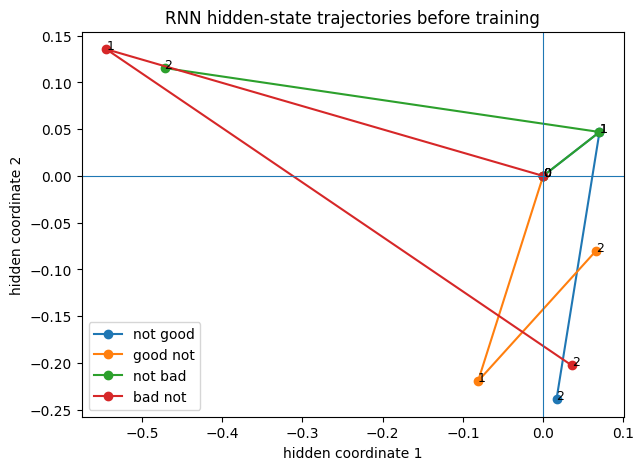

In [7]:
plt.figure(figsize=(7, 5))
for s in sentences:
    H = hidden_trajectory(s, params_demo)
    plt.plot(H[:, 0], H[:, 1], marker="o", label=s)
    for t, (x, y) in enumerate(H[:, :2]):
        plt.text(x, y, str(t), fontsize=9)
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.xlabel("hidden coordinate 1")
plt.ylabel("hidden coordinate 2")
plt.title("RNN hidden-state trajectories before training")
plt.legend()
plt.show()

## 4. Many-to-one sequence classification

For sentence classification, we often use the final hidden state $h_T$ and map it to class probabilities:

$$
z = W_y h_T + b_y,
$$

$$
\hat p = \operatorname{softmax}(z).
$$

For a true class label $y$, the cross-entropy loss is

$$
L = -\log \hat p_y.
$$

Next, we train the tiny RNN classifier from scratch. The code is intentionally explicit so that each derivative can be connected to the equations.

In [8]:
def cross_entropy(probs, y):
    return -np.log(probs[y] + 1e-12)

def predict_label(text, params):
    ids = encode(tokenize(text))
    probs = rnn_forward(ids, params, return_cache=False)
    return int(np.argmax(probs)), probs

def evaluate_dataset(dataset, params):
    correct = 0
    rows = []
    for text, y in dataset:
        pred, probs = predict_label(text, params)
        correct += int(pred == y)
        rows.append({
            "text": text,
            "true": y,
            "pred": pred,
            "p_positive": probs[1],
        })
    return correct / len(dataset), pd.DataFrame(rows)

params = initialize_rnn(len(vocab), hidden_dim=8, seed=5)
acc0, df0 = evaluate_dataset(examples, params)
print("Initial training accuracy:", acc0)
df0.head()

Initial training accuracy: 0.5


,text,true,pred,p_positive
0,good,1,0,0.383714
1,very good,1,0,0.443947
2,really good,1,0,0.367812
3,excellent,1,0,0.419631
4,not bad,1,0,0.432140


## 5. Backpropagation through time from scratch

Backpropagation through time, or BPTT, is ordinary backpropagation applied to the unrolled computational graph

$$
h_1 \to h_2 \to \cdots \to h_T.
$$

For a single example, the output derivative begins with

$$
\frac{\partial L}{\partial z} = \hat p - y_{\text{one-hot}}.
$$

Then the gradient flows backward from $h_T$ to $h_{T-1}$, from $h_{T-1}$ to $h_{T-2}$, and so on. At each time step, the derivative of $\tanh(a)$ is

$$
1 - \tanh^2(a).
$$

The implementation below computes exact gradients for the small RNN classifier.

In [9]:
def rnn_loss_and_grads(ids, y, params):
    Wx, Wh, bh, Wy, by = params["Wx"], params["Wh"], params["bh"], params["Wy"], params["by"]
    probs, cache = rnn_forward(ids, params)
    loss = cross_entropy(probs, y)
    hs = cache["hs"]
    T = len(ids)
    hidden_dim = Wh.shape[0]
    h0 = np.zeros(hidden_dim)
    hs_prev = [h0] + hs[:-1]

    grads = {k: np.zeros_like(v) for k, v in params.items()}

    dlogits = probs.copy()
    dlogits[y] -= 1.0
    grads["Wy"] += np.outer(dlogits, hs[-1])
    grads["by"] += dlogits

    dh = Wy.T @ dlogits
    for t in reversed(range(T)):
        h_t = hs[t]
        h_prev = hs_prev[t]
        idx = ids[t]
        da = dh * (1 - h_t ** 2)
        grads["bh"] += da
        grads["Wx"][:, idx] += da
        grads["Wh"] += np.outer(da, h_prev)
        dh = Wh.T @ da

    return loss, grads

def global_grad_norm(grads):
    return float(np.sqrt(sum(np.sum(g ** 2) for g in grads.values())))

ids, y = encoded[0]
loss, grads = rnn_loss_and_grads(ids, y, params)
print("Example:", examples[0])
print("Loss:", loss)
print("Gradient norm:", global_grad_norm(grads))
for k, g in grads.items():
    print(k, g.shape)

Example: ('good', 1)
Loss: 0.9578578982293023
Gradient norm: 1.4692109988994946
Wx (8, 13)
Wh (8, 8)
bh (8,)
Wy (2, 8)
by (2,)


### Gradient checking

For one parameter entry, we can compare the analytic gradient to a finite-difference approximation:

$$
\frac{L(\theta + \epsilon) - L(\theta - \epsilon)}{2\epsilon}.
$$

This is slow but useful for debugging small neural networks.

In [10]:
def finite_difference_check(params, ids, y, name="Wh", index=(0, 0), eps=1e-5):
    params_plus = {k: v.copy() for k, v in params.items()}
    params_minus = {k: v.copy() for k, v in params.items()}
    params_plus[name][index] += eps
    params_minus[name][index] -= eps
    p_plus = rnn_forward(ids, params_plus, return_cache=False)
    p_minus = rnn_forward(ids, params_minus, return_cache=False)
    loss_plus = cross_entropy(p_plus, y)
    loss_minus = cross_entropy(p_minus, y)
    return (loss_plus - loss_minus) / (2 * eps)

loss, grads = rnn_loss_and_grads(encoded[1][0], encoded[1][1], params)
analytic = grads["Wh"][0, 0]
numeric = finite_difference_check(params, encoded[1][0], encoded[1][1], name="Wh", index=(0, 0))
print("Analytic gradient:", analytic)
print("Numeric gradient: ", numeric)
print("Absolute difference:", abs(analytic - numeric))

Analytic gradient: 0.04103458186451062
Numeric gradient:  0.04103458186022202
Absolute difference: 4.288604193991574e-12


## 6. Training with gradient clipping

RNN gradients can become large because the same recurrent matrix is used repeatedly. A common practical tool is **gradient clipping**:

$$
g \leftarrow g \cdot \min\left(1, \frac{c}{\lVert g \rVert}\right),
$$

where $c$ is a chosen threshold.

The function below trains the RNN using stochastic gradient descent. Since the dataset is tiny, each epoch loops through all training examples.

In [11]:
def clip_grads(grads, max_norm=5.0):
    norm = global_grad_norm(grads)
    if norm > max_norm:
        scale = max_norm / (norm + 1e-12)
        for k in grads:
            grads[k] *= scale
    return norm

def train_rnn(dataset, params, epochs=250, lr=0.08, clip=5.0, seed=0):
    local_rng = np.random.default_rng(seed)
    history = []
    for epoch in range(1, epochs + 1):
        order = local_rng.permutation(len(dataset))
        losses = []
        grad_norms = []
        for i in order:
            text, y = dataset[i]
            ids = encode(tokenize(text))
            loss, grads = rnn_loss_and_grads(ids, y, params)
            norm_before = clip_grads(grads, max_norm=clip)
            for k in params:
                params[k] -= lr * grads[k]
            losses.append(loss)
            grad_norms.append(norm_before)
        if epoch % 10 == 0 or epoch == 1:
            acc, _ = evaluate_dataset(dataset, params)
            history.append({
                "epoch": epoch,
                "loss": float(np.mean(losses)),
                "grad_norm": float(np.mean(grad_norms)),
                "accuracy": acc,
            })
    return pd.DataFrame(history)

params_trained = initialize_rnn(len(vocab), hidden_dim=8, seed=8)
history = train_rnn(examples, params_trained, epochs=300, lr=0.08, clip=3.0, seed=4)
history.tail()

,epoch,loss,grad_norm,accuracy
26,260,0.002946,0.021927,1.0
27,270,0.002800,0.020860,1.0
28,280,0.002668,0.019885,1.0
29,290,0.002547,0.019010,1.0
30,300,0.002436,0.018199,1.0


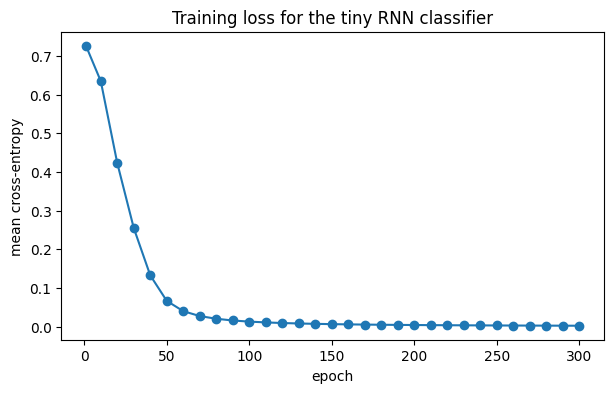

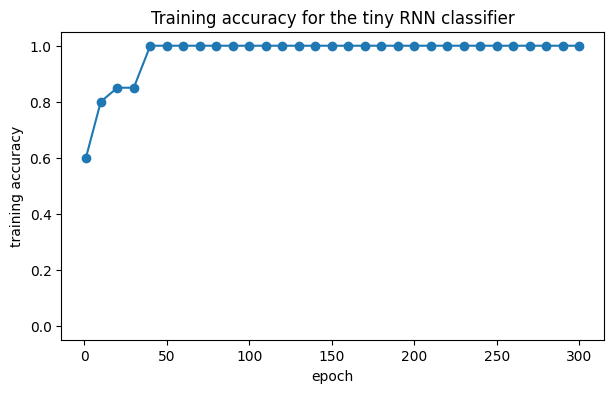

In [12]:
plt.figure(figsize=(7, 4))
plt.plot(history["epoch"], history["loss"], marker="o")
plt.xlabel("epoch")
plt.ylabel("mean cross-entropy")
plt.title("Training loss for the tiny RNN classifier")
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history["epoch"], history["accuracy"], marker="o")
plt.xlabel("epoch")
plt.ylabel("training accuracy")
plt.ylim(-0.05, 1.05)
plt.title("Training accuracy for the tiny RNN classifier")
plt.show()

In [13]:
train_acc, train_table = evaluate_dataset(examples, params_trained)
test_acc, test_table = evaluate_dataset(test_examples, params_trained)
print("Training accuracy:", train_acc)
print("Test accuracy:", test_acc)
print("\nTraining predictions")
display(train_table)
print("\nHeld-out prediction check")
display(test_table)

Training accuracy: 1.0
Test accuracy: 1.0

Training predictions


,text,true,pred,p_positive
0,good,1,1,0.997866
1,very good,1,1,0.999259
2,really good,1,1,0.999521
3,excellent,1,1,0.997568
4,not bad,1,1,0.997614
5,not terrible,1,1,0.994871
6,not boring,1,1,0.995336
7,movie good,1,1,0.999603
8,story excellent,1,1,0.999436
9,acting not bad,1,1,0.996919



Held-out prediction check


,text,true,pred,p_positive
0,good,1,1,0.997866
1,not good,0,0,0.004490
2,bad,0,0,0.001726
3,not bad,1,1,0.997614
4,story not terrible,1,1,0.994422
5,movie not excellent,0,0,0.017301


## 7. Inspecting order sensitivity

The trained RNN reads tokens sequentially, so the hidden state after **not** can affect how the next word is interpreted.

We compare predictions for order-sensitive pairs.

In [14]:
probe_sentences = [
    "good", "not good", "good not",
    "bad", "not bad", "bad not",
    "excellent", "not excellent",
    "terrible", "not terrible",
]

rows = []
for s in probe_sentences:
    pred, probs = predict_label(s, params_trained)
    rows.append({"sentence": s, "predicted_label": pred, "p_positive": probs[1]})
probe_table = pd.DataFrame(rows)
display(probe_table)

,sentence,predicted_label,p_positive
0,good,1,0.997866
1,not good,0,0.004490
2,good not,0,0.000225
3,bad,0,0.001726
4,not bad,1,0.997614
5,bad not,0,0.001558
6,excellent,1,0.997568
7,not excellent,0,0.006179
8,terrible,0,0.002856
9,not terrible,1,0.994871


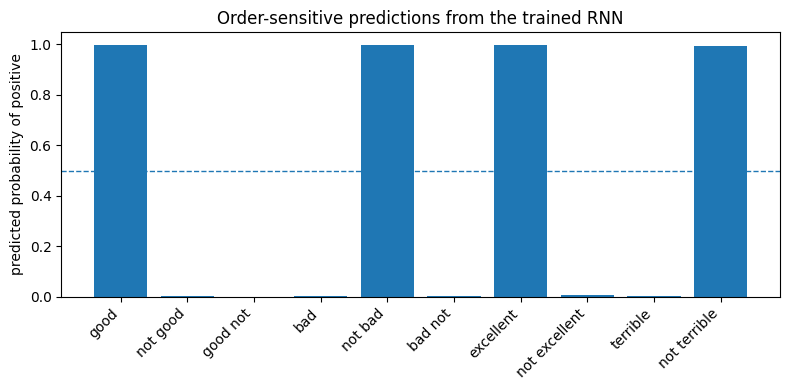

In [15]:
plt.figure(figsize=(8, 4))
plt.bar(probe_table["sentence"], probe_table["p_positive"])
plt.axhline(0.5, linestyle="--", linewidth=1)
plt.xticks(rotation=45, ha="right")
plt.ylabel("predicted probability of positive")
plt.title("Order-sensitive predictions from the trained RNN")
plt.tight_layout()
plt.show()

## 8. Visualizing trained hidden-state trajectories

After training, hidden trajectories should become more organized for the classification task. The plot below shows the first two hidden coordinates for several short sequences.

In a real model, hidden states may have hundreds or thousands of dimensions. Here the small hidden dimension makes the geometry easier to inspect.

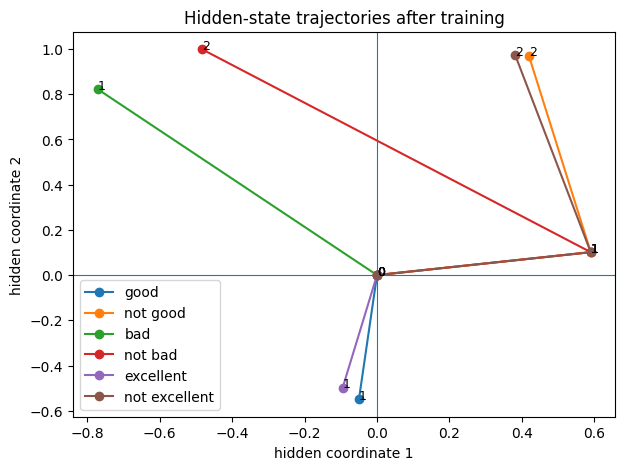

In [16]:
plt.figure(figsize=(7, 5))
for s in ["good", "not good", "bad", "not bad", "excellent", "not excellent"]:
    H = hidden_trajectory(s, params_trained)
    plt.plot(H[:, 0], H[:, 1], marker="o", label=s)
    for t, (x, y) in enumerate(H[:, :2]):
        plt.text(x, y, str(t), fontsize=9)
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.xlabel("hidden coordinate 1")
plt.ylabel("hidden coordinate 2")
plt.title("Hidden-state trajectories after training")
plt.legend()
plt.show()

## 9. Vanishing and exploding gradients

The main difficulty in training vanilla RNNs comes from repeated multiplication by Jacobian matrices. In a simplified linear recurrence

$$
h_t = a h_{t-1},
$$

the derivative of $h_T$ with respect to $h_0$ is

$$
\frac{\partial h_T}{\partial h_0} = a^T.
$$

If $|a|<1$, this goes to zero as $T$ grows. If $|a|>1$, this grows quickly.

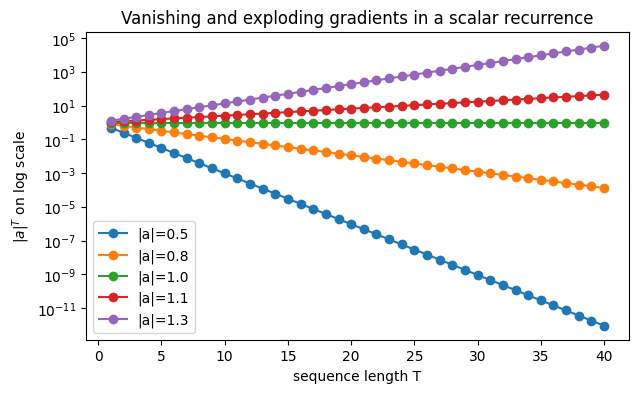

In [17]:
T_values = np.arange(1, 41)
a_values = [0.5, 0.8, 1.0, 1.1, 1.3]
plt.figure(figsize=(7, 4))
for a in a_values:
    plt.plot(T_values, np.abs(a) ** T_values, marker="o", label=f"|a|={a}")
plt.yscale("log")
plt.xlabel("sequence length T")
plt.ylabel(r"$|a|^T$ on log scale")
plt.title("Vanishing and exploding gradients in a scalar recurrence")
plt.legend()
plt.show()

### Spectral radius viewpoint

For a linear vector recurrence

$$
h_t = W_h h_{t-1},
$$

gradients involve powers of $W_h$. A key quantity is the spectral radius, the largest absolute eigenvalue of $W_h$:

$$
\rho(W_h) = \max_i |\lambda_i|.
$$

Roughly speaking, if the spectral radius is far below $1$, memory tends to decay; if it is far above $1$, signals can grow unstable.

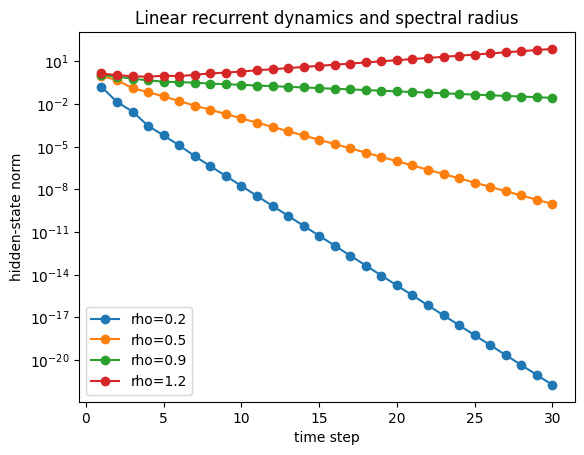

In [18]:
def spectral_radius(A):
    return float(np.max(np.abs(np.linalg.eigvals(A))))

base = rng.normal(size=(4, 4))
for scale in [0.2, 0.5, 0.9, 1.2]:
    W = scale * base / spectral_radius(base)
    h = rng.normal(size=4)
    norms = []
    for _ in range(30):
        h = W @ h
        norms.append(np.linalg.norm(h))
    plt.plot(range(1, 31), norms, marker="o", label=f"rho={spectral_radius(W):.1f}")
plt.yscale("log")
plt.xlabel("time step")
plt.ylabel("hidden-state norm")
plt.title("Linear recurrent dynamics and spectral radius")
plt.legend()
plt.show()

## 10. A small RNN language-model forward pass

A language model predicts the next token. For a sequence

$$
x_1,x_2,\ldots,x_T,
$$

an RNN language model estimates

$$
p(x_2,\ldots,x_T \mid x_1)
= \prod_{t=1}^{T-1} p(x_{t+1} \mid x_1,\ldots,x_t).
$$

The next code block builds a tiny untrained RNN language model forward pass. The purpose is not to get good predictions, but to understand the shape of the computation.

In [19]:
def initialize_rnn_lm(vocab_size, hidden_dim=10, scale=0.15, seed=0):
    local_rng = np.random.default_rng(seed)
    return {
        "Wx": local_rng.normal(0, scale, size=(hidden_dim, vocab_size)),
        "Wh": local_rng.normal(0, scale, size=(hidden_dim, hidden_dim)),
        "bh": np.zeros(hidden_dim),
        "Wy": local_rng.normal(0, scale, size=(vocab_size, hidden_dim)),
        "by": np.zeros(vocab_size),
    }

def rnn_lm_forward(ids, params):
    Wx, Wh, bh, Wy, by = params["Wx"], params["Wh"], params["bh"], params["Wy"], params["by"]
    h = np.zeros(Wh.shape[0])
    probs_list = []
    states = []
    for idx in ids[:-1]:
        h = np.tanh(Wx[:, idx] + Wh @ h + bh)
        probs = softmax(Wy @ h + by)
        probs_list.append(probs)
        states.append(h.copy())
    return probs_list, states

lm_params = initialize_rnn_lm(len(vocab), hidden_dim=10, seed=12)
sentence = "not bad"
ids = encode(tokenize(sentence))
probs_list, states = rnn_lm_forward(ids, lm_params)
for t, probs in enumerate(probs_list):
    current_word = itos[ids[t]]
    true_next_word = itos[ids[t+1]]
    top = np.argsort(-probs)[:5]
    print(f"After reading '{current_word}', true next word is '{true_next_word}'.")
    print([(itos[i], float(probs[i])) for i in top])

After reading 'not', true next word is 'bad'.
[('boring', 0.08534334925374593), ('not', 0.08295418286434955), ('very', 0.08242127320896057), ('<unk>', 0.08063682386659901), ('really', 0.07928520508805466)]


### Per-token negative log-likelihood

For language modeling, the loss over a sentence is the sum of next-token losses:

$$
L = - \sum_{t=1}^{T-1} \log p(x_{t+1} \mid x_1,\ldots,x_t).
$$

The average loss per predicted token gives cross-entropy, and exponentiating cross-entropy gives perplexity.

In [20]:
def rnn_lm_nll(ids, params):
    probs_list, _ = rnn_lm_forward(ids, params)
    nll = 0.0
    for t, probs in enumerate(probs_list):
        target = ids[t + 1]
        nll += -np.log(probs[target] + 1e-12)
    return nll

for s in ["not good", "not bad", "movie good", "story terrible"]:
    ids = encode(tokenize(s))
    if len(ids) > 1:
        nll = rnn_lm_nll(ids, lm_params)
        ce = nll / (len(ids) - 1)
        ppl = np.exp(ce)
        print(f"{s:15s} NLL={nll:.3f}, cross-entropy={ce:.3f}, perplexity={ppl:.3f}")

not good        NLL=2.536, cross-entropy=2.536, perplexity=12.630
not bad         NLL=2.695, cross-entropy=2.695, perplexity=14.803
movie good      NLL=2.552, cross-entropy=2.552, perplexity=12.831
story terrible  NLL=2.514, cross-entropy=2.514, perplexity=12.356


## 11. RNNs versus n-grams

An $n$-gram model predicts from a fixed-size context. For example, a bigram model uses only the previous token:

$$
p(x_t \mid x_1,\ldots,x_{t-1}) pprox p(x_t \mid x_{t-1}).
$$

An RNN can, in principle, use a variable-length prefix summarized by $h_t$. This does not mean vanilla RNNs solve all long-context problems, but it explains why recurrence was historically important for language modeling.

In [21]:
def bigram_counts(sentences):
    counts = defaultdict(Counter)
    for text, _ in sentences:
        toks = ["<s>"] + tokenize(text) + ["</s>"]
        for a, b in zip(toks[:-1], toks[1:]):
            counts[a][b] += 1
    return counts

def bigram_prob(next_word, prev_word, counts, alpha=0.5):
    all_words = set()
    for c in counts.values():
        all_words.update(c.keys())
    all_words.update(counts.keys())
    V = len(all_words)
    total = sum(counts[prev_word].values())
    return (counts[prev_word][next_word] + alpha) / (total + alpha * V)

bc = bigram_counts(examples)
for prev in ["not", "very", "story", "movie"]:
    candidates = ["good", "bad", "excellent", "terrible", "boring"]
    ranked = sorted([(w, bigram_prob(w, prev, bc)) for w in candidates], key=lambda x: -x[1])
    print(prev, "->", ranked)

not -> [('good', 0.18518518518518517), ('bad', 0.18518518518518517), ('excellent', 0.1111111111111111), ('terrible', 0.1111111111111111), ('boring', 0.1111111111111111)]
very -> [('good', 0.17647058823529413), ('bad', 0.17647058823529413), ('excellent', 0.058823529411764705), ('terrible', 0.058823529411764705), ('boring', 0.058823529411764705)]
story -> [('excellent', 0.17647058823529413), ('terrible', 0.17647058823529413), ('good', 0.058823529411764705), ('bad', 0.058823529411764705), ('boring', 0.058823529411764705)]
movie -> [('good', 0.17647058823529413), ('bad', 0.17647058823529413), ('excellent', 0.058823529411764705), ('terrible', 0.058823529411764705), ('boring', 0.058823529411764705)]


## 12. Exercises

Complete these exercises by editing or adding code cells.

### Exercise 1 — Change the hidden dimension
Train RNNs with hidden dimensions $2$, $4$, $8$, and $16$. How does training accuracy change? Does a larger hidden dimension always help on this tiny dataset?

### Exercise 2 — Remove gradient clipping
Set `clip=None` by modifying the training loop, or use a very large clipping value such as `1e9`. Compare the training curves. Do you see instability?

### Exercise 3 — More order-sensitive examples
Add training examples such as:

- `not very good`
- `not very bad`
- `not really excellent`
- `not really terrible`

Does the RNN learn these longer negation patterns?

### Exercise 4 — Replace tanh with ReLU
Modify the recurrence to use ReLU instead of tanh. What happens to hidden-state norms and training stability?

### Exercise 5 — Bigram comparison
Train or evaluate a simple bigram classifier. Find examples where the RNN and bigram model behave differently.

## 13. Mini-project — Order sensitivity in text classification

Design a small experiment showing that order matters.

### Suggested plan

1. Create a dataset of at least 40 short sentences.
2. Include pairs whose bag-of-words vectors are similar or identical but whose meanings differ.
3. Train a bag-of-words logistic regression or Naive Bayes model.
4. Train the RNN classifier from this lab.
5. Compare predictions on carefully designed test sentences.
6. Write a short report answering:
   - Which examples require word order?
   - Which examples are handled by bag-of-words?
   - Where does the RNN fail?
   - How might LSTMs, GRUs, or attention improve the result?

### AI-assisted reflection prompt

After completing your experiment, ask an AI assistant to critique your dataset design. Then verify the critique yourself. Do not accept the AI response automatically; use it as a source of hypotheses.

## 14. Summary

In this lab, you implemented a vanilla RNN as a recurrent dynamical system:

$$
h_t = \tanh(W_h h_{t-1} + W_x e_t + b_h).
$$

You used the final hidden state for sequence classification, trained the model with backpropagation through time, visualized hidden trajectories, and studied vanishing and exploding gradients.

The key conceptual message is:

> An RNN replaces an unordered document vector with a state that evolves as tokens are read in order.

This idea prepares you for gated recurrent models, attention, and transformers.